**Problem 1**. Consider a sample $X_n = \{x_1, \ldots, x_n\}$ of i.i.d. observations from Pareto distribution with PDF:

$$
f_X(x) = 
\begin{cases} 
\frac{\alpha x_m^\alpha}{x^{\alpha+1}} & x \geqslant x_m \\
0 & \text{otherwise}
\end{cases}
$$

with (unknown) parameters $x_m > 0$ (called scale), and $\alpha > 0$ (called shape). Denote $\theta = (\alpha, x_m)$.

<Figure size 1200x800 with 0 Axes>

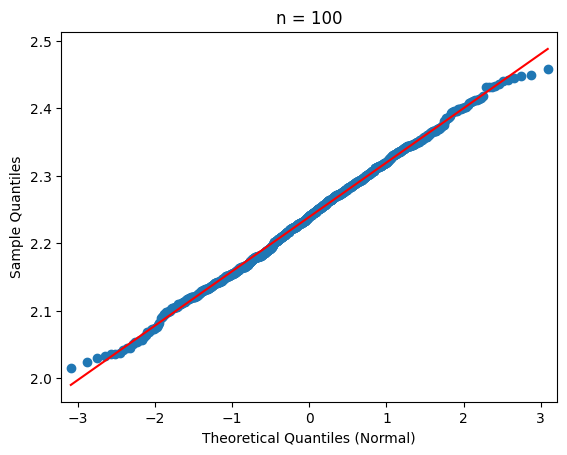

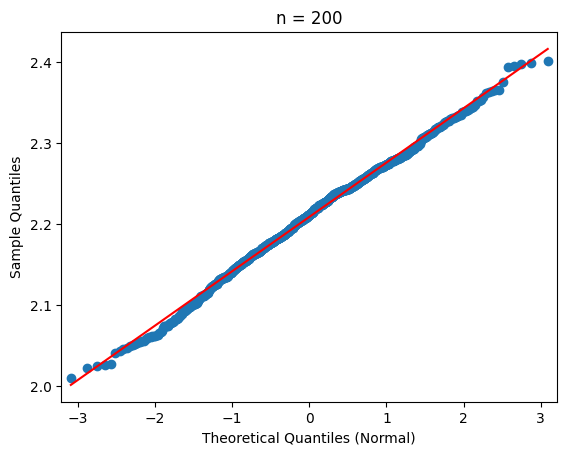

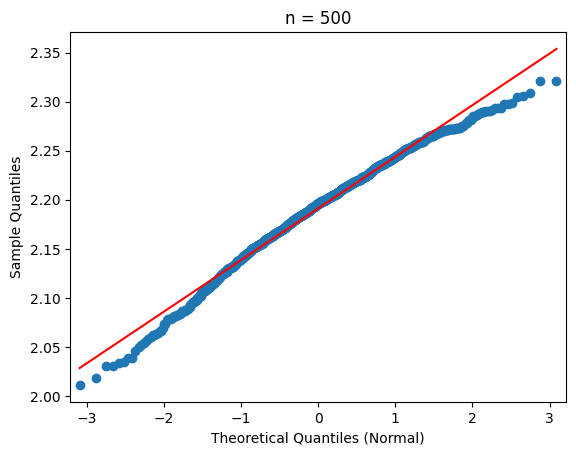

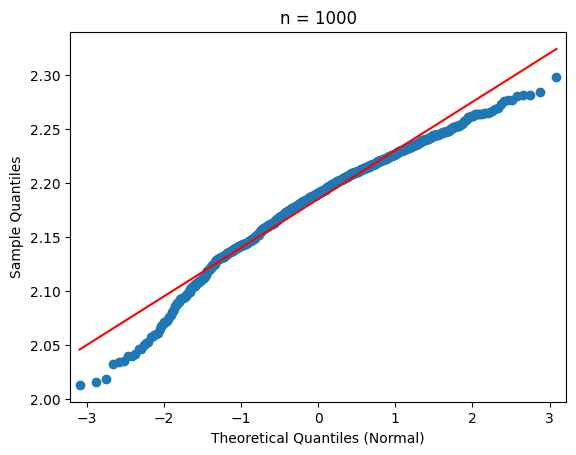

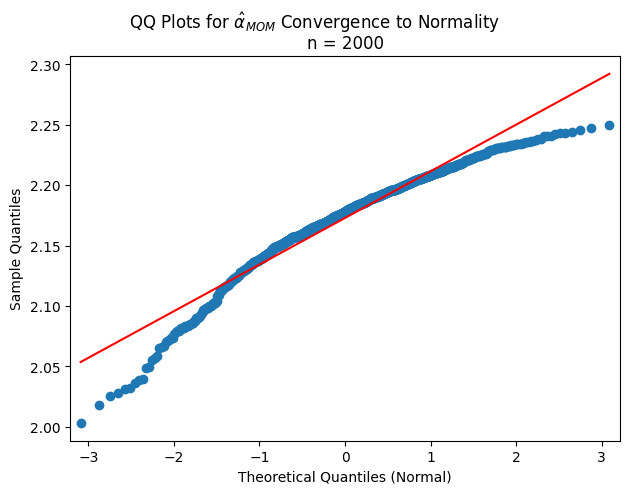

n = 100: Mean = 2.2393, Var = 0.0065
n = 200: Mean = 2.2090, Var = 0.0045
n = 500: Mean = 2.1911, Var = 0.0028
n = 1000: Mean = 2.1853, Var = 0.0020
n = 2000: Mean = 2.1730, Var = 0.0015


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot

# True parameters
alpha_true = 3.0  # Must be >2 for MOM to exist
xm_true = 2.0

# Sample sizes to test
sample_sizes = [100, 200, 500, 1000, 2000]

# Number of simulations per sample size
n_simulations = 1000

# Store MOM estimates for alpha
alpha_mom_estimates = {n: [] for n in sample_sizes}

# Simulate data and compute MOM estimates
for n in sample_sizes:
    for _ in range(n_simulations):
        # Generate Pareto samples
        sample = np.random.pareto(alpha_true, size=n) * xm_true
        
        # Compute MOM estimates
        m1 = np.mean(sample)
        m2 = np.mean(sample**2)
        s2 = m2 - m1**2
        
        if s2 <= 0:
            continue  # Skip if variance is non-positive (unlikely for alpha>2)
        
        alpha_hat = 1 + np.sqrt(m2 / s2)
        xm_hat = m1 * (alpha_hat - 1) / alpha_hat
        
        alpha_mom_estimates[n].append(alpha_hat)

# Plot QQ plots for each sample size
plt.figure(figsize=(12, 8))
for i, n in enumerate(sample_sizes, 1):
    #plt.subplot(2, 3, i)
    qqplot(np.array(alpha_mom_estimates[n]), line='s');
    plt.title(f"n = {n}")
    plt.xlabel("Theoretical Quantiles (Normal)")
    plt.ylabel("Sample Quantiles")

plt.tight_layout()
plt.suptitle("QQ Plots for $\hat{\\alpha}_{MOM}$ Convergence to Normality", y=1.02)
plt.show();

# Print mean and variance of estimates
for n in sample_sizes:
    alphas = np.array(alpha_mom_estimates[n])
    print(f"n = {n}: Mean = {np.mean(alphas):.4f}, Var = {np.var(alphas, ddof=1):.4f}")